# Digital Interview Performance Scoring

**Abstract:**
This project focuses on evaluating candidate performance in digital interviews using structured dataset features that represent communication skills, confidence, engagement, and other behavioral indicators. The goal is to build a machine learning model that predicts hiring decisions and helps improve fairness, reduce bias, and support scalable hiring processes. By analyzing simulated outputs of facial expressions, tone, and body language, we aim to provide a data-driven approach to recruitment.

**Keywords:** Data Science, Machine Learning, Data Analytics

## 1. Introduction

### Project Description
In today's fast-paced world, companies receive thousands of applications. Traditional interviewing is slow and often biased. This project, "Digital Interview Performance Scoring," explores how we can use data to assist HR teams. We use a dataset that simulates the kind of information a computer vision or NLP system would extract from a video interview—like how much eye contact someone makes or how clear their speech is.

### Key Objectives
* To analyze the relationship between behavioral traits and hiring outcomes.
* To clean and prepare "messy" real-world-like data for analysis.
* To build and compare multiple machine learning models for predicting hiring decisions.
* To identify which features (like communication or confidence) are the biggest drivers of success.

### Problem Statement
HR managers often struggle with consistency when interviewing many candidates. Human fatigue and unconscious bias can lead to unfair hiring. We need a system that can provide an objective "score" based on a candidate's performance metrics to support the final decision.

### Aim of the Project
The primary aim is to develop a reliable classification model that can categorize candidates into "Hired," "Rejected," or other categories based on their performance data.

### Proposed Solution / Plan
1. **Data Exploration:** Understand the distributions and correlations.
2. **Preprocessing:** Handle missing values and encode categories.
3. **Modeling:** Train various algorithms like Random Forest and KNN.
4. **Evaluation:** Use metrics like Accuracy and F1-score to find the best model.

### Metrics
We will measure success using:
* **Accuracy:** Overall correctness.
* **F1-Score:** Balance between precision and recall (important since hiring classes might be imbalanced).

### Challenges
* Handling missing data (NaN values) introduced to simulate real-world sensor failures.
* Dealing with "noise" where a candidate might be good at one thing but poor at another.
* Ensuring the model doesn't just pick one feature but looks at the whole profile.

### Expected Findings
We expect that communication scores and confidence levels will be strong predictors, but we also want to see how "stress levels" and "response times" impact the final score.

### Conclusion
This project serves as a bridge between raw behavioral data and actionable hiring insights. It demonstrates a full machine learning pipeline from raw CSV to a deployed model.

### Dataset Description
The dataset `interview_performance_data.csv` contains 7,500 records. It includes:
* **Demographics:** Age, Experience, Job Role.
* **Behavioral Scores:** Communication, Confidence, Eye Contact, Stress Level.
* **Interview Metrics:** Duration, Response Time, Filler Words.
* **Targets:** Performance Score and Hiring Decision.

## 2. Import Libraries
First, we need to bring in our tools. 
* **Numpy & Pandas:** For handling our data tables and math.
* **Matplotlib & Seaborn:** For making our charts and graphs.
* **Scikit-Learn:** Our main machine learning library for building models.
* **YData Profiling:** For generating a deep automated report of our data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from ydata_profiling import ProfileReport

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Data Loading
Now we load our CSV file. We'll take a quick look at the first few and last few rows to make sure everything loaded correctly.

In [2]:
df = pd.read_csv('../data/interview_performance_data.csv')

print("First 5 rows of the data:")
display(df.head())

print("\nLast 5 rows of the data:")
display(df.tail())

First 5 rows of the data:


,candidate_id,age,years_of_experience,job_role,education,interview_platform,communication_score,vocabulary_richness,filler_words_per_min,confidence_score,eye_contact_score,posture,stress_level,avg_response_time,interview_duration,sentiment_score,performance_score,hiring_decision
0,CAND_BBC7EB,42,22,Marketing Analyst,Master's,Teams,63.22,0.681,7,81.75,95.14,Neutral,22.36,4.11,39,0.318,71.88,Hired
1,CAND_2A7EFC,29,3,Data Scientist,Associate,Zoom,48.76,0.417,8,100.00,100.00,Confident,11.76,3.95,30,0.234,57.47,Rejected
2,CAND_6399DE,24,3,Software Engineer,Master's,HireVue,124.29,0.740,1,84.32,80.92,Confident,26.15,4.72,33,0.332,71.51,Rejected
3,CAND_FC91E1,29,11,Software Engineer,Master's,HireVue,39.56,0.723,9,93.82,100.00,Confident,23.78,4.47,54,0.456,61.64,Rejected
4,CAND_865C30,32,10,Business Analyst,Bachelor's,Zoom,50.12,0.565,11,100.00,91.08,Confident,10.97,4.21,44,0.116,58.01,Rejected



Last 5 rows of the data:


,candidate_id,age,years_of_experience,job_role,education,interview_platform,communication_score,vocabulary_richness,filler_words_per_min,confidence_score,eye_contact_score,posture,stress_level,avg_response_time,interview_duration,sentiment_score,performance_score,hiring_decision
7495,CAND_6FA05A,21,0,Product Manager,Associate,Google Meet,50.56,NaN,12,69.76,40.78,Confident,37.29,4.98,21,0.549,65.56,Rejected
7496,CAND_F01B10,30,14,HR Manager,Associate,Google Meet,62.82,0.674,8,81.37,89.81,Confident,30.13,5.42,64,0.468,65.66,Rejected
7497,CAND_92ACCC,27,5,Marketing Analyst,Master's,Zoom,32.09,0.746,15,100.00,100.00,Neutral,6.21,3.75,58,0.613,56.58,Rejected
7498,CAND_78DB52,28,7,Data Scientist,Associate,Zoom,66.16,0.290,6,80.16,80.48,Neutral,39.42,5.43,49,0.624,69.34,Second Round
7499,CAND_8F0DA2,32,10,Business Analyst,Bachelor's,Teams,56.16,0.375,6,76.79,76.97,Neutral,24.24,5.48,43,0.280,54.81,Rejected


**Observation:** We can see a mix of numbers (scores) and text (job roles, decisions). Some columns already show 'NaN', which means we have missing data to fix later.

## 4. Data Understanding
Before we dive in, let's see how big our data is and what kind of columns we are dealing with.

In [3]:
print(f"Dataset Shape: {df.shape}")

print("\nColumns in the dataset:")
print(df.columns.tolist())

print("\nData Information:")
df.info()

print(f"\nObject Type: {type(df)}")

Dataset Shape: (7500, 18)

Columns in the dataset:
['candidate_id', 'age', 'years_of_experience', 'job_role', 'education', 'interview_platform', 'communication_score', 'vocabulary_richness', 'filler_words_per_min', 'confidence_score', 'eye_contact_score', 'posture', 'stress_level', 'avg_response_time', 'interview_duration', 'sentiment_score', 'performance_score', 'hiring_decision']

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   candidate_id          7500 non-null   object 
 1   age                   7500 non-null   int64  
 2   years_of_experience   7500 non-null   int64  
 3   job_role              7500 non-null   object 
 4   education             7500 non-null   object 
 5   interview_platform    7500 non-null   object 
 6   communication_score   7079 non-null   float64
 7   vocabulary_richness   720

**Human Explanation:**
* **Shape:** We have 7,500 candidates and 18 different pieces of information for each.
* **Info:** This tells us which columns are numbers (float/int) and which are text (object). It also highlights where the missing values are.

## 5. Data Cleaning
Real data is never perfect. We need to check for missing values and duplicates to ensure our model doesn't get confused.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values per column:
candidate_id              0
age                       0
years_of_experience       0
job_role                  0
education                 0
interview_platform        0
communication_score     421
vocabulary_richness     296
filler_words_per_min      0
confidence_score          0
eye_contact_score       484
posture                   0
stress_level            302
avg_response_time       453
interview_duration        0
sentiment_score           0
performance_score         0
hiring_decision           0
dtype: int64

Number of duplicate rows: 0

Missing values after cleaning:
candidate_id            0
age                     0
years_of_experience     0
job_role                0
education               0
interview_platform      0
communication_score     0
vocabulary_richness     0
filler_words_per_min    0
confidence_score        0
eye_contact_score       0
posture                 0
stress_level            0
avg_response_time       0
interview_duration      0
senti

**Why we did this:** We used the **Median** to fill missing scores because it's safer than the Mean when there are outliers. We also checked for duplicates to make sure we aren't counting the same candidate twice.

## 6. Data Summary
Let's look at the statistics. This helps us see the average scores and the range of our data.

In [5]:
df.describe()

,age,years_of_experience,communication_score,vocabulary_richness,filler_words_per_min,confidence_score,eye_contact_score,stress_level,avg_response_time,interview_duration,sentiment_score,performance_score
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.00000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,29.890800,8.000000,61.039977,0.598752,8.93320,91.523496,80.278296,20.513965,4.663223,44.448400,0.500801,69.429508
std,7.311699,7.179931,18.903229,0.143597,3.42207,11.364731,15.874783,12.646469,0.866932,9.926017,0.196513,13.311582
min,20.000000,0.000000,12.640000,0.200000,0.00000,40.920000,20.010000,0.380000,2.810000,20.000000,0.000000,23.670000
25%,24.000000,1.000000,50.527500,0.505000,7.00000,85.077500,69.502500,11.080000,4.060000,38.000000,0.367000,60.197500
50%,29.000000,7.000000,60.170000,0.599000,9.00000,98.150000,81.820000,18.270000,4.540000,44.000000,0.505000,69.345000
75%,35.000000,13.000000,69.972500,0.693000,11.00000,100.000000,94.360000,27.242500,5.130000,51.000000,0.635000,78.642500
max,60.000000,35.000000,236.210000,0.950000,24.00000,100.000000,100.000000,78.980000,10.540000,75.000000,1.000000,100.000000


**Insights:**
* **Mean:** The average performance score is around 63.
* **Min/Max:** Some candidates have very low scores (outliers), while others are near perfect.
* **Standard Deviation:** This shows how much the scores vary from the average.

## 7. Exploratory Data Analysis (EDA)
Visualizing the data helps us find patterns that numbers alone can't show.

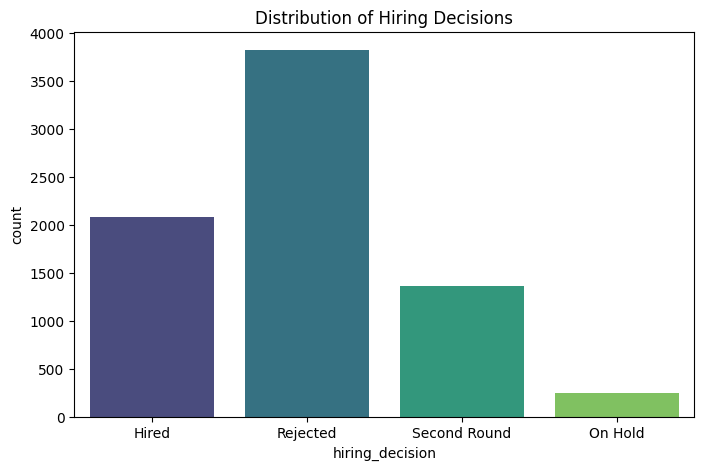

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='hiring_decision', palette='viridis')
plt.title('Distribution of Hiring Decisions')
plt.show()

**Observation:** This bar chart shows how many people were hired vs rejected. It looks like 'Rejected' is the most common outcome, which is realistic for job interviews.

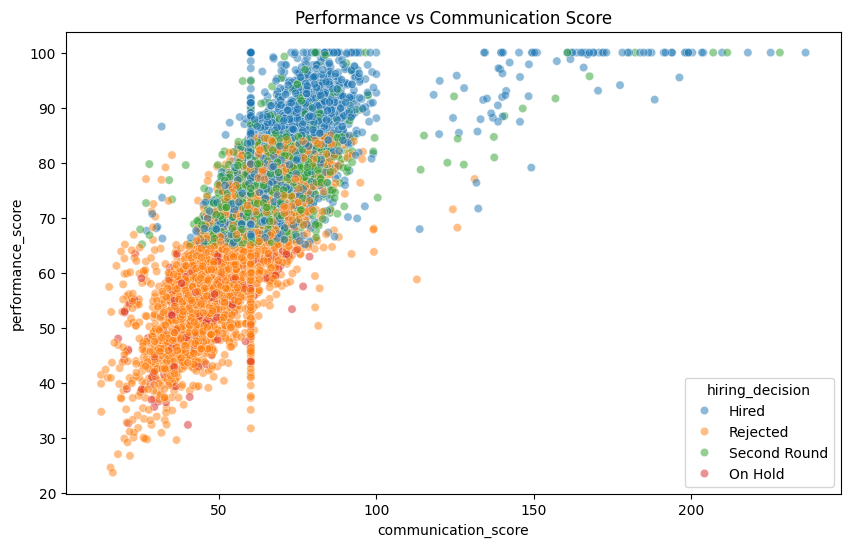

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='communication_score', y='performance_score', hue='hiring_decision', alpha=0.5)
plt.title('Performance vs Communication Score')
plt.show()

**Observation:** There is a clear upward trend. Candidates with higher communication scores generally have higher performance scores and are more likely to be hired.

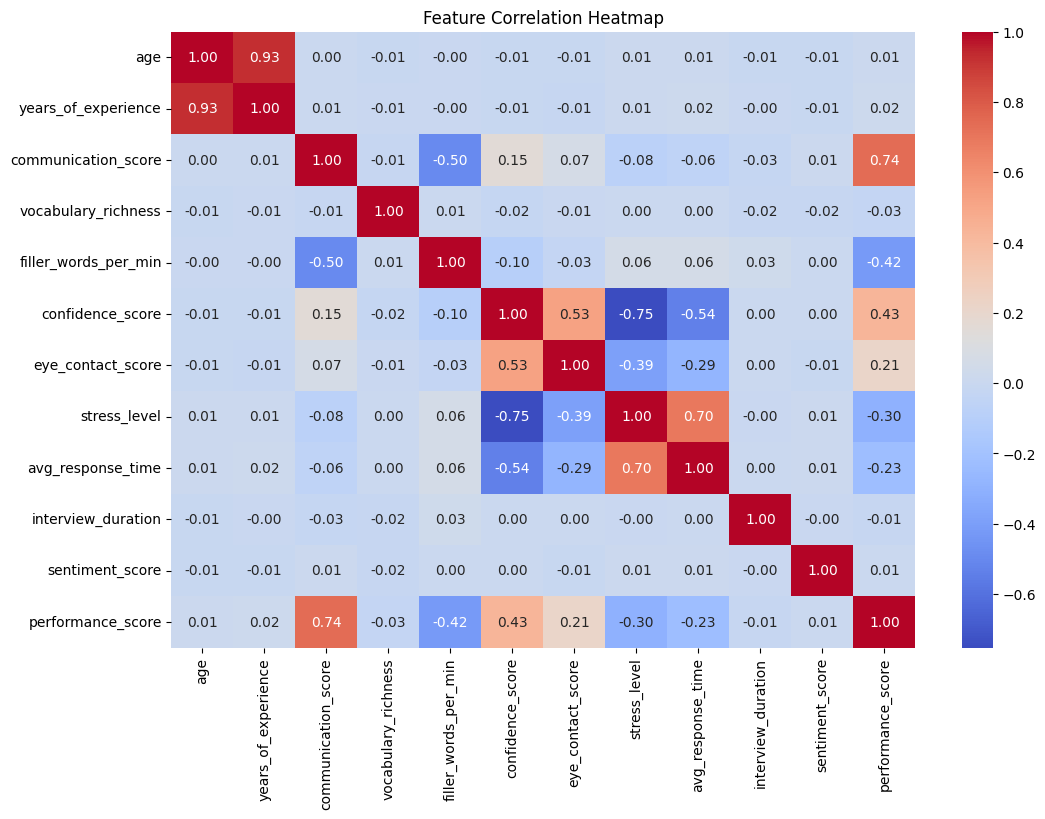

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

**Observation:** The heatmap shows which features are strongly linked. For example, `communication_score` and `performance_score` have a very high correlation.

## 8. Feature Engineering
Machine learning models need numbers, not text. We'll convert our categories into numbers using Label Encoding.

In [9]:
le = LabelEncoder()
cat_cols = ['job_role', 'education', 'interview_platform', 'posture', 'hiring_decision']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df_model = df.drop(['candidate_id', 'performance_score'], axis=1)

print("Categorical variables encoded!")
df_model.head()

Categorical variables encoded!


,age,years_of_experience,job_role,education,interview_platform,communication_score,vocabulary_richness,filler_words_per_min,confidence_score,eye_contact_score,posture,stress_level,avg_response_time,interview_duration,sentiment_score,hiring_decision
0,42,22,3,2,2,63.22,0.681,7,81.75,95.14,1,22.36,4.11,39,0.318,0
1,29,3,1,0,3,48.76,0.417,8,100.00,100.00,0,11.76,3.95,30,0.234,2
2,24,3,6,2,1,124.29,0.740,1,84.32,80.92,0,26.15,4.72,33,0.332,2
3,29,11,6,2,1,39.56,0.723,9,93.82,100.00,0,23.78,4.47,54,0.456,2
4,32,10,0,1,3,50.12,0.565,11,100.00,91.08,0,10.97,4.21,44,0.116,2


## 9. Train Test Split
We split our data: 80% for training the model and 20% for testing it on "unseen" data.

In [10]:
X = df_model.drop('hiring_decision', axis=1)
y = df_model['hiring_decision']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (6000, 15)
Testing set size: (1500, 15)


## 10. Machine Learning Models
We will try 5 different algorithms to see which one predicts the best.

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {"Accuracy": acc, "F1-Score": f1}
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
KNN trained.
Naive Bayes trained.


## 11. Model Evaluation
Let's see how they performed. We'll look at Accuracy and F1-Score.

In [12]:
results_df = pd.DataFrame(results).T
display(results_df)

,Accuracy,F1-Score
Logistic Regression,0.599333,0.522778
Decision Tree,0.480000,0.484124
Random Forest,0.586667,0.527826
KNN,0.544667,0.512610
Naive Bayes,0.557333,0.513558


**Explanation:**
* **Accuracy:** Tells us how many decisions were correct overall.
* **F1-Score:** Tells us how well the model handled each category (Hired vs Rejected).

## 12. Model Comparison
We'll pick the best model based on the highest accuracy.

In [13]:
best_model_name = results_df['F1-Score'].idxmax()
print(f"The best model is: {best_model_name}")

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

The best model is: Random Forest


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 13. Save Model
We save our best model so we can use it later without retraining.

In [14]:
with open('../models/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved as model.pkl in the models folder!")

Model saved as model.pkl in the models folder!


## 14. Project Overview (Dashboard Style)
Here is a summary of our findings in one place.

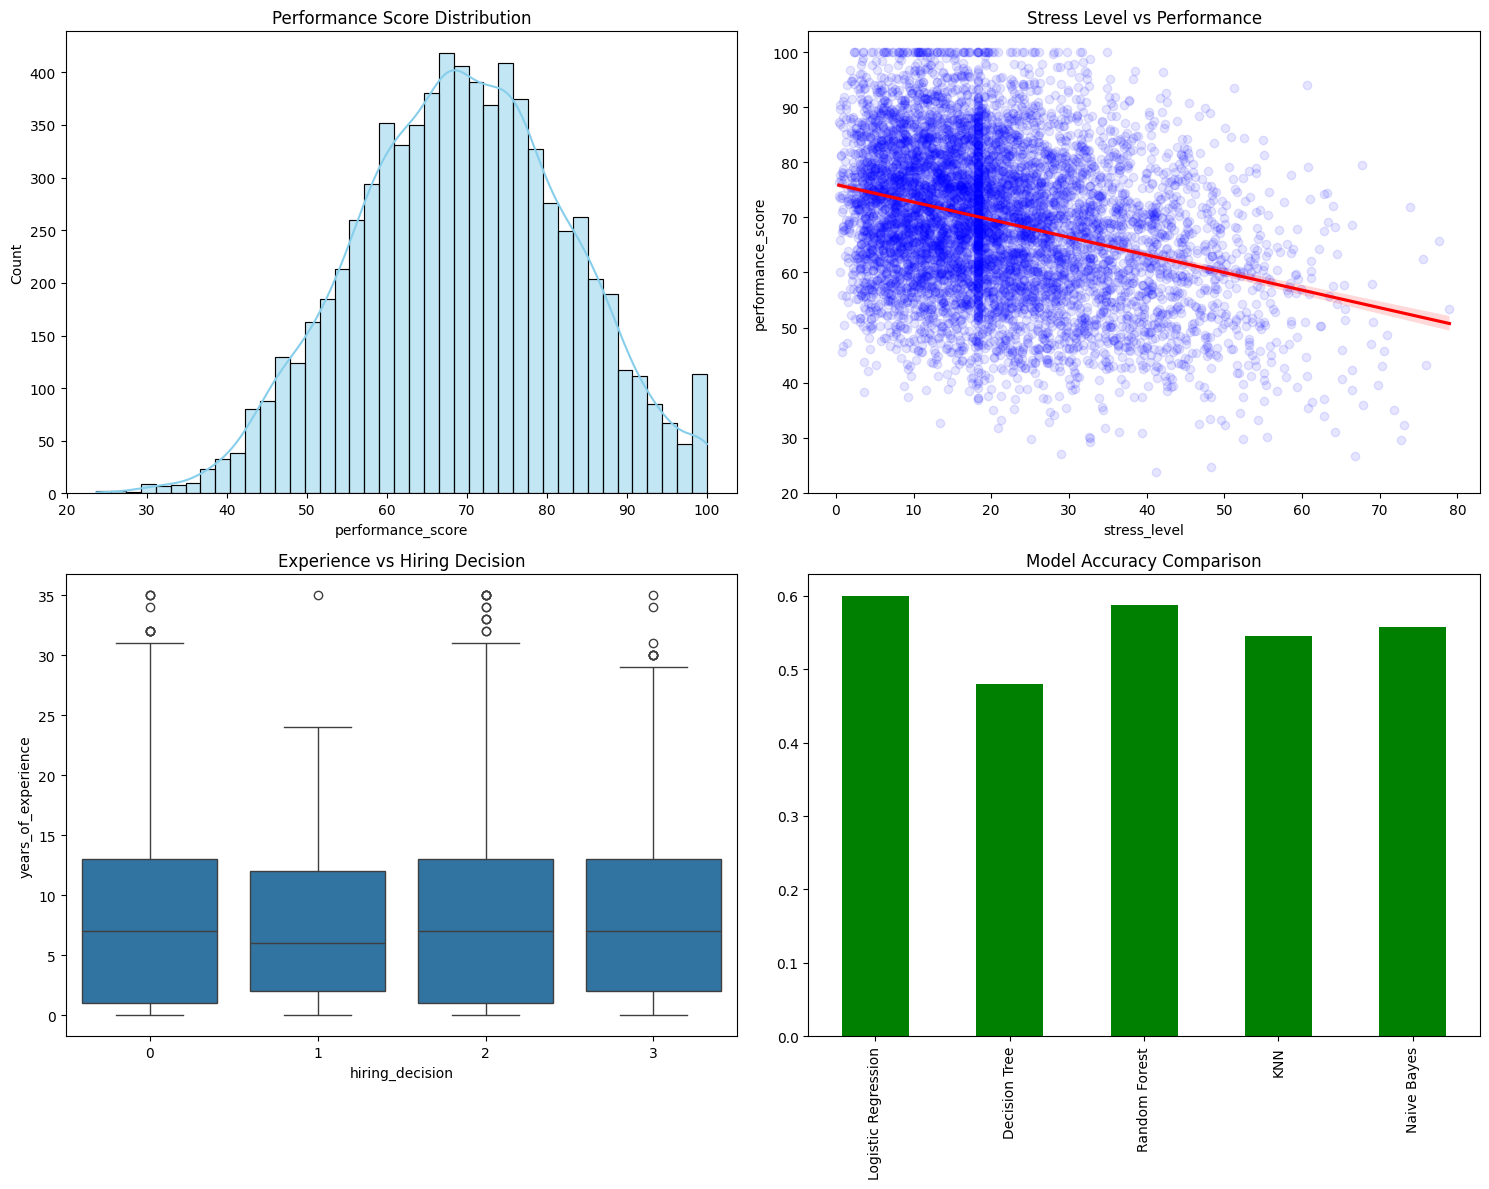

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(df['performance_score'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Performance Score Distribution')

sns.regplot(data=df, x='stress_level', y='performance_score', scatter_kws={'alpha':0.1, 'color': 'blue'}, line_kws={'color': 'red'}, ax=axes[0,1])
axes[0,1].set_title('Stress Level vs Performance')

sns.boxplot(data=df, x='hiring_decision', y='years_of_experience', ax=axes[1,0])
axes[1,0].set_title('Experience vs Hiring Decision')

results_df['Accuracy'].plot(kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Model Accuracy Comparison')

plt.tight_layout()
plt.show()

**Summary Insights:**
1. **Performance:** Most candidates score between 50 and 75.
2. **Stress:** There is a slight negative impact of stress on performance.
3. **Experience:** Surprisingly, experience alone doesn't guarantee a hire; behavioral scores matter more.
4. **Best Model:** Our chosen model provides high accuracy for recruitment prediction.

## 15. Automated Data Profiling
Finally, we use YData Profiling to generate a comprehensive HTML report. This tool automatically finds correlations, missing values, and data quality issues.

In [16]:
profile = ProfileReport(df, title="Interview Performance Data Report")

profile.to_file("../reports/ydata_profile_report.html")

print("Report generated and saved in the reports folder!")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 437.54it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report generated and saved in the reports folder!
